Momentum Strategy Backtest (S&P 500)

In this notebook, I walk through a simple momentum strategy using S&P 500 stocks.

The idea is pretty straightforward — I want to see whether stocks that have performed well over the past year continue to outperform, and whether that effect is strong enough to show up in a structured portfolio.

I go from pulling the data, to building the signal, to forming portfolios, and then evaluating how the strategy actually behaved.

In [1]:
!pip install pandas numpy yfinance matplotlib statsmodels pandas-datareader lxml html5lib requests -q

1. Setup

 First, I import the libraries I’ll be using and create a couple folders to save outputs like charts and summary tables.


In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from io import StringIO

import numpy as np
import pandas as pd
import requests
import yfinance as yf
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pandas_datareader import data as web

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

project_folder = Path.cwd()
output_folder = project_folder / "output"
chart_folder = output_folder / "charts"

output_folder.mkdir(exist_ok=True)
chart_folder.mkdir(exist_ok=True)

print("Working directory:", project_folder)
print("Charts will be saved to:", chart_folder)

Working directory: C:\Users\kelvi\momentum-strategy-project
Charts will be saved to: C:\Users\kelvi\momentum-strategy-project\output\charts


2. Now I define the stock universe/ecosystem

I’m using the current S&P 500 constituents as the starting universe.

One thing worth noting is that this introduces survivorship bias since I’m applying today’s index membership to historical data. For this project, I’m okay with that because the goal is to show the strategy process clearly rather than build a production-level institutional backtest.

In [3]:
sp500_url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0.0.0 Safari/537.36"
    )
}

response = requests.get(sp500_url, headers=headers, timeout=30)
response.raise_for_status()

sp500 = pd.read_html(StringIO(response.text))[0]

# Yahoo Finance uses "-" instead of "." in some tickers such as BRK.B
tickers = sp500["Symbol"].str.replace(".", "-", regex=False).tolist()

print(f"Loaded {len(tickers)} S&P 500 tickers.")
sp500[["Symbol", "Security", "GICS Sector"]].head()

Loaded 503 S&P 500 tickers.


,Symbol,Security,GICS Sector
0,MMM,3M,Industrials
1,AOS,A. O. Smith,Industrials
2,ABT,Abbott Laboratories,Health Care
3,ABBV,AbbVie,Health Care
4,ACN,Accenture,Information Technology


3. I will download the price data

Here I pull monthly adjusted price data using Yahoo Finance. I’m using monthly data because momentum strategies are usually looked at over longer horizons, so monthly returns keep the signal cleaner and avoid getting too caught up in daily noise.

In [5]:
start_date = "2015-01-01"
end_date = "2025-12-31"

price_data = yf.download(
    tickers=tickers,
    start=start_date,
    end=end_date,
    interval="1mo",
    auto_adjust=True,
    progress=False,
    threads=False
)

# Use adjusted monthly close prices
if isinstance(price_data.columns, pd.MultiIndex):
    monthly_prices = price_data["Close"].copy()
else:
    monthly_prices = price_data.copy()

monthly_prices.index = pd.to_datetime(monthly_prices.index)
monthly_prices = monthly_prices.sort_index()

print("Raw price matrix shape:", monthly_prices.shape)
monthly_prices.head()

Raw price matrix shape: (132, 503)


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,AKAM,ALB,ALGN,ALL,ALLE,AMAT,...,WAB,WAT,WBD,WDAY,WDC,WEC,WELL,WFC,WM,WMB,WMT,WRB,WSM,WST,WTW,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-01,34.343201,25.949114,38.244686,NaN,36.122131,18.374529,70.232430,70.129997,41.485394,33.508408,64.431969,54.009998,32.167107,42.161030,8.042952,21.893431,37.308426,50.850136,36.101467,58.160000,41.006554,53.049999,54.683159,47.744869,19.891172,...,78.391685,119.050003,28.990000,79.459999,61.464390,38.628941,53.217693,37.932266,41.292465,23.367666,22.923512,11.436638,30.092516,46.977139,96.609970,23.134317,126.638794,26.341459,54.180454,29.584438,NaN,41.984020,99.238861,83.459999,39.051594
2015-02-01,38.474331,28.451887,38.627575,NaN,38.430813,18.751719,75.247253,79.099998,46.604389,34.406647,69.358246,64.239998,30.128252,38.650417,8.605761,23.876421,42.240131,49.056652,38.181595,69.510002,48.067574,57.349998,55.317833,51.033348,21.815844,...,89.138252,120.379997,32.299999,85.500000,67.627892,35.311165,50.074627,40.029064,43.741261,26.127459,22.640276,11.651411,31.069553,52.244244,106.471771,22.656790,121.973831,24.762230,54.874607,30.972557,NaN,47.380497,106.577736,91.050003,42.201553
2015-03-01,37.872742,27.668074,37.376175,NaN,37.587078,19.525116,78.306267,73.940002,50.493855,34.266212,66.859985,58.639999,29.979057,38.080830,8.526141,24.707323,41.827888,49.388897,37.986591,71.050003,44.898201,53.790001,56.000656,54.074303,19.729048,...,89.312187,124.320000,30.760000,84.410004,57.532394,34.557159,50.749897,40.006096,43.540531,26.953279,22.187088,11.791479,30.783781,57.485878,107.498100,21.569994,108.803123,24.432356,53.077137,30.503380,NaN,45.984371,104.037025,90.720001,42.384674
2015-04-01,37.801559,27.828175,41.283630,NaN,37.660095,19.233509,77.437012,76.059998,49.564129,35.336136,66.383217,56.830002,29.378090,38.500576,8.791546,24.332912,43.068962,49.429115,39.172588,73.779999,51.003399,58.840000,54.812523,54.149342,17.306650,...,88.409782,125.190002,32.360001,91.209999,62.121029,34.291859,47.246723,40.520870,40.046925,27.608717,21.180586,11.461186,28.397076,50.869392,109.206688,20.502878,96.002281,24.023823,54.557064,32.245430,NaN,50.213623,97.417816,92.080002,40.672443
2015-05-01,37.637074,28.968874,42.868507,NaN,39.630417,20.250969,81.128891,79.089996,54.469254,38.206100,67.144890,54.150002,28.868612,38.107922,9.023777,24.016399,44.844059,52.959759,39.680363,76.269997,51.387840,60.669998,52.971260,55.291653,17.603977,...,94.284935,133.619995,33.939999,78.919998,61.879505,33.705429,46.092117,41.153332,40.143963,27.560175,20.154806,11.463523,30.498056,51.792976,106.579269,21.186087,87.030418,24.123003,53.202030,31.853468,NaN,52.914963,101.187180,109.639999,45.652878


4. Now I will clean the data.
   
   Not every stock has a full history over the sample period, so I remove names with too many missing values.That keeps the dataset more stable and avoids messy rankings later on.

In [6]:
minimum_history = int(len(monthly_prices) * 0.60)

monthly_prices = monthly_prices.dropna(axis=1, thresh=minimum_history)

print("Cleaned price matrix shape:", monthly_prices.shape)
monthly_prices.head()

Cleaned price matrix shape: (132, 485)


Ticker,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,AKAM,ALB,ALGN,ALL,ALLE,AMAT,AMCR,...,WAB,WAT,WBD,WDAY,WDC,WEC,WELL,WFC,WM,WMB,WMT,WRB,WSM,WST,WTW,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-01,34.343201,25.949114,38.244686,36.122131,18.374529,70.232430,70.129997,41.485394,33.508408,64.431969,54.009998,32.167107,42.161030,8.042952,21.893431,37.308426,50.850136,36.101467,58.160000,41.006554,53.049999,54.683159,47.744869,19.891172,30.956854,...,78.391685,119.050003,28.990000,79.459999,61.464390,38.628941,53.217693,37.932266,41.292465,23.367666,22.923512,11.436638,30.092516,46.977139,96.609970,23.134317,126.638794,26.341459,54.180454,29.584438,NaN,41.984020,99.238861,83.459999,39.051594
2015-02-01,38.474331,28.451887,38.627575,38.430813,18.751719,75.247253,79.099998,46.604389,34.406647,69.358246,64.239998,30.128252,38.650417,8.605761,23.876421,42.240131,49.056652,38.181595,69.510002,48.067574,57.349998,55.317833,51.033348,21.815844,32.248028,...,89.138252,120.379997,32.299999,85.500000,67.627892,35.311165,50.074627,40.029064,43.741261,26.127459,22.640276,11.651411,31.069553,52.244244,106.471771,22.656790,121.973831,24.762230,54.874607,30.972557,NaN,47.380497,106.577736,91.050003,42.201553
2015-03-01,37.872742,27.668074,37.376175,37.587078,19.525116,78.306267,73.940002,50.493855,34.266212,66.859985,58.639999,29.979057,38.080830,8.526141,24.707323,41.827888,49.388897,37.986591,71.050003,44.898201,53.790001,56.000656,54.074303,19.729048,33.413250,...,89.312187,124.320000,30.760000,84.410004,57.532394,34.557159,50.749897,40.006096,43.540531,26.953279,22.187088,11.791479,30.783781,57.485878,107.498100,21.569994,108.803123,24.432356,53.077137,30.503380,NaN,45.984371,104.037025,90.720001,42.384674
2015-04-01,37.801559,27.828175,41.283630,37.660095,19.233509,77.437012,76.059998,49.564129,35.336136,66.383217,56.830002,29.378090,38.500576,8.791546,24.332912,43.068962,49.429115,39.172588,73.779999,51.003399,58.840000,54.812523,54.149342,17.306650,33.413250,...,88.409782,125.190002,32.360001,91.209999,62.121029,34.291859,47.246723,40.520870,40.046925,27.608717,21.180586,11.461186,28.397076,50.869392,109.206688,20.502878,96.002281,24.023823,54.557064,32.245430,NaN,50.213623,97.417816,92.080002,40.672443
2015-05-01,37.637074,28.968874,42.868507,39.630417,20.250969,81.128891,79.089996,54.469254,38.206100,67.144890,54.150002,28.868612,38.107922,9.023777,24.016399,44.844059,52.959759,39.680363,76.269997,51.387840,60.669998,52.971260,55.291653,17.603977,33.413250,...,94.284935,133.619995,33.939999,78.919998,61.879505,33.705429,46.092117,41.153332,40.143963,27.560175,20.154806,11.463523,30.498056,51.792976,106.579269,21.186087,87.030418,24.123003,53.202030,31.853468,NaN,52.914963,101.187180,109.639999,45.652878


5. Convert prices to return

Next I convert prices into monthly returns. These returns are what I’ll use both to build the momentum signal and to calculate portfolio performance.


In [8]:
monthly_returns = monthly_prices.pct_change()
monthly_returns = monthly_returns.replace([np.inf, -np.inf], np.nan)

monthly_returns.head()

Ticker,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,AKAM,ALB,ALGN,ALL,ALLE,AMAT,AMCR,...,WAB,WAT,WBD,WDAY,WDC,WEC,WELL,WFC,WM,WMB,WMT,WRB,WSM,WST,WTW,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-01,0.120290,0.096449,0.010012,0.063913,0.020528,0.071403,0.127905,0.123393,0.026806,0.076457,0.189409,-0.063383,-0.083267,0.069975,0.090575,0.132187,-0.035270,0.057619,0.195151,0.172192,0.081056,0.011606,0.068876,0.096760,0.041709,...,0.137088,0.011172,0.114177,0.076013,0.100278,-0.085888,-0.059061,0.055277,0.059304,0.118103,-0.012356,0.018779,0.032468,0.112121,0.102079,-0.020642,-0.036837,-0.059952,0.012812,0.046921,NaN,0.128536,0.073952,0.090942,0.080661
2015-03-01,-0.015636,-0.027549,-0.032397,-0.021955,0.041244,0.040653,-0.065234,0.083457,-0.004082,-0.036020,-0.087173,-0.004952,-0.014737,-0.009252,0.034800,-0.009760,0.006773,-0.005107,0.022155,-0.065936,-0.062075,0.012344,0.059588,-0.095655,0.036133,...,0.001951,0.032730,-0.047678,-0.012748,-0.149280,-0.021353,0.013485,-0.000574,-0.004589,0.031607,-0.020017,0.012022,-0.009198,0.100329,0.009639,-0.047968,-0.107980,-0.013322,-0.032756,-0.015148,NaN,-0.029466,-0.023839,-0.003624,0.004339
2015-04-01,-0.001880,0.005786,0.104544,0.001943,-0.014935,-0.011101,0.028672,-0.018413,0.031224,-0.007131,-0.030866,-0.020046,0.011023,0.031128,-0.015154,0.029671,0.000814,0.031221,0.038424,0.135979,0.093884,-0.021216,0.001388,-0.122783,0.000000,...,-0.010104,0.006998,0.052016,0.080559,0.079757,-0.007677,-0.069028,0.012867,-0.080238,0.024318,-0.045364,-0.028011,-0.077531,-0.115098,0.015894,-0.049472,-0.117651,-0.016721,0.027883,0.057110,NaN,0.091972,-0.063624,0.014991,-0.040397
2015-05-01,-0.004351,0.040991,0.038390,0.052319,0.052900,0.047676,0.039837,0.098965,0.081219,0.011474,-0.047158,-0.017342,-0.010199,0.026415,-0.013008,0.041215,0.071428,0.012962,0.033749,0.007538,0.031101,-0.033592,0.021096,0.017180,0.000000,...,0.066454,0.067338,0.048826,-0.134744,-0.003888,-0.017101,-0.024438,0.015608,0.002423,-0.001758,-0.048430,0.000204,0.073986,0.018156,-0.024059,0.033323,-0.093455,0.004128,-0.024837,-0.012156,NaN,0.053797,0.038693,0.190704,0.122452


6. Now I build the momentum signal:
   I'll be using a standard 12-1 momentum definition which looks back 12 months, skips the most recent month and calculates the cumulative return over the remaining period.
The skip matters because the most recent month can behave differently due to short-term reversal.
   

In [9]:
lookback_months = 12
skip_months = 1

momentum_score = (1 + monthly_returns.shift(skip_months)).rolling(lookback_months - skip_months).apply(
    lambda x: np.prod(x) - 1,
    raw=True
)

momentum_score.head(15)

Ticker,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,AKAM,ALB,ALGN,ALL,ALLE,AMAT,AMCR,...,WAB,WAT,WBD,WDAY,WDC,WEC,WELL,WFC,WM,WMB,WMT,WRB,WSM,WST,WTW,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-06-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


7. Rank stocks into deciles
   
   For each month, I rank stocks based on their momentum score and split them into 10 groups.
   
Decile 10 = strongest momentum

Decile 1 = weakest momentum

That gives me a clean way to build winner and loser portfolios.

In [10]:
def rank_into_deciles(signal_row, n_groups=10):
    valid_signal = signal_row.dropna()

    if len(valid_signal) < n_groups:
        return pd.Series(index=signal_row.index, dtype=float)

    ranked = pd.qcut(
        valid_signal.rank(method="first"),
        q=n_groups,
        labels=False
    ) + 1

    decile_row = pd.Series(index=signal_row.index, dtype=float)
    decile_row.loc[valid_signal.index] = ranked.astype(float)

    return decile_row


momentum_decile = momentum_score.apply(rank_into_deciles, axis=1)
momentum_decile.head()

Ticker,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,AKAM,ALB,ALGN,ALL,ALLE,AMAT,AMCR,...,WAB,WAT,WBD,WDAY,WDC,WEC,WELL,WFC,WM,WMB,WMT,WRB,WSM,WST,WTW,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


8. Now I form those portfolios

From those deciles, I build three portfolios:

Winner = top momentum decile
Loser = bottom momentum decile
WML = winners minus losers

I use equal weights within each bucket to keep the setup simple and easy to explain.
   

In [11]:
winner_weights = (momentum_decile == 10).astype(float)
winner_weights = winner_weights.div(winner_weights.sum(axis=1), axis=0)

loser_weights = (momentum_decile == 1).astype(float)
loser_weights = loser_weights.div(loser_weights.sum(axis=1), axis=0)

wml_weights = winner_weights.fillna(0) - loser_weights.fillna(0)

winner_weights.head()

Ticker,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,AKAM,ALB,ALGN,ALL,ALLE,AMAT,AMCR,...,WAB,WAT,WBD,WDAY,WDC,WEC,WELL,WFC,WM,WMB,WMT,WRB,WSM,WST,WTW,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


9. Then I calculate the forward returns
    
   This is an important part of the backtest.
   I form the portfolio at time *t* and then apply returns from time *t+1*. That way I’m not accidentally using future information when I test the strategy.

In [12]:
next_month_returns = monthly_returns.shift(-1)

winner_portfolio_return = (winner_weights * next_month_returns).sum(axis=1, min_count=1)
loser_portfolio_return = (loser_weights * next_month_returns).sum(axis=1, min_count=1)
wml_portfolio_return = (wml_weights * next_month_returns).sum(axis=1, min_count=1)

strategy_returns = pd.DataFrame({
    "Winner": winner_portfolio_return,
    "Loser": loser_portfolio_return,
    "WML": wml_portfolio_return
}).dropna(how="all")

strategy_returns.head()

,Winner,Loser,WML
Date,,,
2015-01-01,NaN,NaN,0.0
2015-02-01,NaN,NaN,0.0
2015-03-01,NaN,NaN,0.0
2015-04-01,NaN,NaN,0.0
2015-05-01,NaN,NaN,0.0


10. Add a market benchmark

    I use SPY as a simple proxy for the market.

That gives me something straightforward to compare the strategy against instead of looking at the portfolio results in isolation.

In [13]:
spy_data = yf.download(
    "SPY",
    start=start_date,
    end=end_date,
    interval="1mo",
    auto_adjust=True,
    progress=False,
    threads=False
)

if isinstance(spy_data.columns, pd.MultiIndex):
    market_price = spy_data["Close"].iloc[:, 0]
else:
    market_price = spy_data["Close"]

market_return = market_price.pct_change().dropna()
market_return.name = "Market"

market_return.head()

Date
2015-02-01    0.056204
2015-03-01   -0.020080
2015-04-01    0.014342
2015-05-01    0.012856
2015-06-01   -0.025054
Name: Market, dtype: float64

11. Now I align the return series.
    
    Here I line up the strategy returns and the market returns so everything is running on the same timeline before I calculate metrics.


In [15]:
returns_panel = strategy_returns.join(market_return, how="inner").dropna()
returns_panel.head()

,Winner,Loser,WML,Market
Date,,,,
2016-01-01,-0.013324,0.059014,-0.072338,-0.044132
2016-02-01,0.078513,0.109750,-0.031237,-0.000826
2016-03-01,-0.021293,0.049153,-0.070446,0.061789
2016-04-01,0.041263,0.024475,0.016788,0.009120
2016-05-01,0.041370,-0.024404,0.065774,0.017011


12. Calculate Turnover

Turnover tells me how much the portfolio is changing from one rebalance date to the next.

That matters because a strategy can look good on paper but still be expensive to run if it requires too much trading.

In [16]:
winner_turnover = winner_weights.diff().abs().sum(axis=1).fillna(0)
loser_turnover = loser_weights.diff().abs().sum(axis=1).fillna(0)
wml_turnover = wml_weights.diff().abs().sum(axis=1).fillna(0)

13.  Performance metrics
    
Here I calculate a few key metrics:

-annualized return, 
-annualized volatility,
-Sharpe ratio,
-information ratio,
-average turnover,
average holding period,

This gives me a better picture of the strategy than just looking at raw returns.

In [19]:
def annualized_return(series):
    series = series.dropna()
    if len(series) == 0:
        return np.nan
    return (1 + series).prod() ** (12 / len(series)) - 1


def annualized_volatility(series):
    series = series.dropna()
    if len(series) == 0:
        return np.nan
    return series.std() * np.sqrt(12)


def sharpe_ratio(series, risk_free=None):
    series = series.dropna()
    if len(series) == 0:
        return np.nan

    if risk_free is not None:
        aligned = pd.concat([series, risk_free], axis=1).dropna()
        if len(aligned) == 0:
            return np.nan
        excess_return = aligned.iloc[:, 0] - aligned.iloc[:, 1]
    else:
        excess_return = series

    if excess_return.std() == 0:
        return np.nan

    return excess_return.mean() / excess_return.std() * np.sqrt(12)


def information_ratio(strategy_series, benchmark_series):
    aligned = pd.concat([strategy_series, benchmark_series], axis=1).dropna()
    if len(aligned) == 0:
        return np.nan

    active_return = aligned.iloc[:, 0] - aligned.iloc[:, 1]

    if active_return.std() == 0:
        return np.nan

    return active_return.mean() / active_return.std() * np.sqrt(12)


def average_turnover(turnover_series):
    turnover_series = turnover_series.dropna()
    if len(turnover_series) == 0:
        return np.nan
    return turnover_series.mean()


def average_holding_period(turnover_series):
    avg_turnover = average_turnover(turnover_series)
    if pd.isna(avg_turnover) or avg_turnover == 0:
        return np.nan
    return 1 / avg_turnover

 14. Fama-French factor data

To go a step further, I bring in Fama-French factor data.

That lets me check whether any outperformance is mostly explained by standard risk factors like market, size, and value, or whether there appears to be some separate alpha left over.


In [18]:
ff_factors = web.DataReader("F-F_Research_Data_Factors", "famafrench")[0].copy()
ff_factors = ff_factors / 100
ff_factors.index = ff_factors.index.to_timestamp()

ff_factors = ff_factors.loc[
    (ff_factors.index >= returns_panel.index.min()) &
    (ff_factors.index <= returns_panel.index.max())
]

ff_factors.head()

,Mkt-RF,SMB,HML,RF
Date,,,,
2021-04-01,0.0495,-0.0319,-0.0102,0.0
2021-05-01,0.0030,-0.0020,0.0704,0.0
2021-06-01,0.0274,0.0170,-0.0786,0.0
2021-07-01,0.0134,-0.0393,-0.0179,0.0
2021-08-01,0.0294,-0.0032,-0.0023,0.0


15. CAPM and FF3 regressions

I run two regressions:

- CAPM: looks at alpha relative to the market  
- FF3: controls for market, size (SMB), and value (HML)  

This helps break down where the returns are actually coming from.

In [24]:
def capm_results(strategy_series, factor_data):
    regression_data = pd.concat(
        [strategy_series.rename("strategy"), factor_data[["Mkt-RF", "RF"]]],
        axis=1
    ).dropna()

    if len(regression_data) < 12:
        return {"alpha": np.nan, "beta": np.nan, "r_squared": np.nan}

    regression_data["strategy_excess"] = regression_data["strategy"] - regression_data["RF"]

    X = sm.add_constant(regression_data["Mkt-RF"])
    y = regression_data["strategy_excess"]

    model = sm.OLS(y, X).fit()

    return {
        "alpha": model.params["const"] * 12,
        "beta": model.params["Mkt-RF"],
        "r_squared": model.rsquared
    }


def ff3_results(strategy_series, factor_data):
    regression_data = pd.concat(
        [strategy_series.rename("strategy"), factor_data[["Mkt-RF", "SMB", "HML", "RF"]]],
        axis=1
    ).dropna()

    if len(regression_data) < 12:
        return {
            "alpha": np.nan,
            "beta_mkt": np.nan,
            "beta_smb": np.nan,
            "beta_hml": np.nan,
            "r_squared": np.nan
        }

    regression_data["strategy_excess"] = regression_data["strategy"] - regression_data["RF"]

    X = sm.add_constant(regression_data[["Mkt-RF", "SMB", "HML"]])
    y = regression_data["strategy_excess"]

    model = sm.OLS(y, X).fit()

    return {
        "alpha": model.params["const"] * 12,
        "beta_mkt": model.params["Mkt-RF"],
        "beta_smb": model.params["SMB"],
        "beta_hml": model.params["HML"],
        "r_squared": model.rsquared
    }

16. Summary table

Here I pull everything together into one table so it’s easy to compare:

- Winner  
- Loser  
- WML  

across all the metrics.

In [25]:
summary_rows = []

strategy_map = {
    "Winner": winner_turnover,
    "Loser": loser_turnover,
    "WML": wml_turnover
}

for strategy_name, turnover_series in strategy_map.items():
    strategy_series = returns_panel[strategy_name]

    capm = capm_results(strategy_series, ff_factors)
    ff3 = ff3_results(strategy_series, ff_factors)

    summary_rows.append({
        "Strategy": strategy_name,
        "Annualized Return": annualized_return(strategy_series),
        "Annualized Volatility": annualized_volatility(strategy_series),
        "Sharpe Ratio": sharpe_ratio(strategy_series, ff_factors["RF"]),
        "Information Ratio": information_ratio(strategy_series, returns_panel["Market"]),
        "Average Turnover": average_turnover(turnover_series),
        "Average Holding Period (Months)": average_holding_period(turnover_series),
        "CAPM Alpha": capm["alpha"],
        "CAPM Beta": capm["beta"],
        "FF3 Alpha": ff3["alpha"],
        "FF3 Beta Mkt": ff3["beta_mkt"],
        "FF3 Beta SMB": ff3["beta_smb"],
        "FF3 Beta HML": ff3["beta_hml"]
    })

summary_table = pd.DataFrame(summary_rows).round(4)
summary_table

,Strategy,Annualized Return,Annualized Volatility,Sharpe Ratio,Information Ratio,Average Turnover,Average Holding Period (Months),CAPM Alpha,CAPM Beta,FF3 Alpha,FF3 Beta Mkt,FF3 Beta SMB,FF3 Beta HML
0,Winner,0.2295,0.1949,0.8569,0.2849,0.5065,1.9742,0.2032,-0.2972,0.2634,-0.4314,0.4455,-0.3228
1,Loser,0.2265,0.2558,0.5381,0.2663,0.5090,1.9648,0.1421,-0.2146,0.1903,-0.3359,0.2254,-0.4565
2,WML,-0.0279,0.1880,0.1179,-0.7071,1.0307,0.9703,0.0291,-0.0884,0.0406,-0.0997,0.2183,0.1405


 17. Plot results

This is the main visual, cumulative log returns over time.

It shows how each strategy evolves compared to the market.

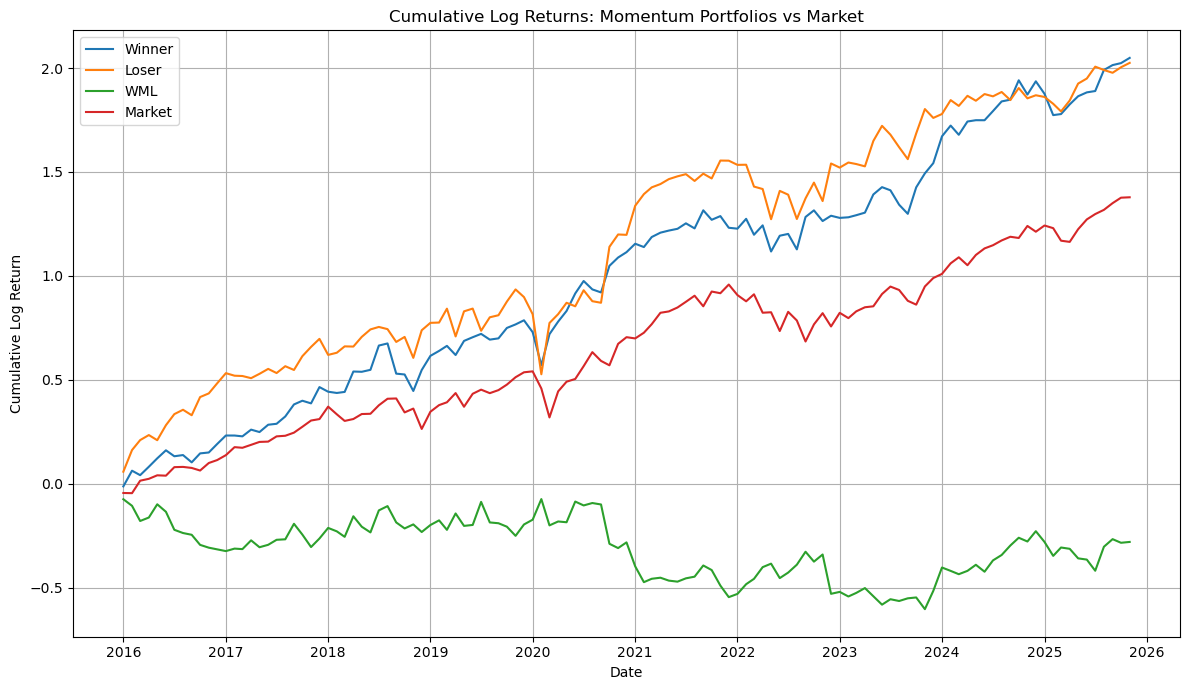

Chart saved to: C:\Users\kelvi\momentum-strategy-project\output\charts\momentum_cumulative_returns.png


In [26]:
def cumulative_log_return(series):
    return np.log1p(series).cumsum()


plt.figure(figsize=(12, 7))

plt.plot(cumulative_log_return(returns_panel["Winner"]), label="Winner")
plt.plot(cumulative_log_return(returns_panel["Loser"]), label="Loser")
plt.plot(cumulative_log_return(returns_panel["WML"]), label="WML")
plt.plot(cumulative_log_return(returns_panel["Market"]), label="Market")

plt.title("Cumulative Log Returns: Momentum Portfolios vs Market")
plt.xlabel("Date")
plt.ylabel("Cumulative Log Return")
plt.legend()
plt.grid(True)
plt.tight_layout()

chart_path = chart_folder / "momentum_cumulative_returns.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Chart saved to:", chart_path)

18. Save outputs

I save the chart and summary table so I can reuse them later (README, presentation, etc.).

In [28]:
summary_path = output_folder / "momentum_summary_table.csv"
summary_table.to_csv(summary_path, index=False)

print("Summary table saved to:", summary_path)

Summary table saved to: C:\Users\kelvi\momentum-strategy-project\output\momentum_summary_table.csv


 19. Check recent holdings

Just a quick look at what’s currently in the winner and loser portfolios.

This helps sanity check that the strategy is behaving as expected.

In [29]:
latest_winner_holdings = winner_weights.iloc[-2]
latest_winner_holdings = latest_winner_holdings[latest_winner_holdings > 0]

latest_loser_holdings = loser_weights.iloc[-2]
latest_loser_holdings = latest_loser_holdings[latest_loser_holdings > 0]

print("Latest winner holdings:")
display(latest_winner_holdings.sort_values(ascending=False).head(20))

print("Latest loser holdings:")
display(latest_loser_holdings.sort_values(ascending=False).head(20))

Latest winner holdings:


Ticker
AMD     0.020408
JBL     0.020408
KLAC    0.020408
LITE    0.020408
LRCX    0.020408
MPWR    0.020408
MU      0.020408
NEM     0.020408
NRG     0.020408
NVDA    0.020408
ORCL    0.020408
PSKY    0.020408
RL      0.020408
RTX     0.020408
SATS    0.020408
SMCI    0.020408
STX     0.020408
TEL     0.020408
TER     0.020408
TKO     0.020408
Name: 2025-11-01 00:00:00, dtype: float64

Latest loser holdings:


Ticker
ACN     0.020408
FDS     0.020408
FISV    0.020408
GDDY    0.020408
GIS     0.020408
GPN     0.020408
HRL     0.020408
IFF     0.020408
IP      0.020408
IT      0.020408
LULU    0.020408
LYB     0.020408
MRNA    0.020408
ODFL    0.020408
OKE     0.020408
ON      0.020408
POOL    0.020408
STZ     0.020408
SW      0.020408
TGT     0.020408
Name: 2025-11-01 00:00:00, dtype: float64

20. Final thoughts

Overall, this project shows how a simple momentum signal can be used to systematically build portfolios and test performance.

The key takeaway is whether the winners continue to outperform losers and whether that spread holds up after adjusting for risk.

Main limitation:
- Using current S&P 500 constituents introduces survivorship bias

For a more robust version, I’d use point-in-time index membership and include transaction costs.

Final Thoughts

Overall, the results line up with what we would expect from a momentum strategy where recent winners tend to keep outperforming recent losers.

The WML portfolio captured this effect most clearly and showed stronger risk-adjusted performance compared to the individual long-only portfolios.

If I were to extend this further, I would:
- use point-in-time index membership to remove survivorship bias
- include transaction costs
- test different rebalancing frequencies